# Phase 4, Part A: SHAP Explainability Setup

The model performance metrics provide confidence in the pipeline's validity, but they describe aggregate performance rather than individual decisions. SHAP (SHapley Additive exPlanations) bridges this gap by quantifying the exact contribution of each feature to a specific prediction. This transparency transforms a black-box risk score into actionable insights, establishing the foundation for fairness audits and customer recourse logic.

Prior to running the explainability notebook, verify that the `shap` library is installed in the local environment:

```bash
pip install shap


In [13]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap

print("shap version:", shap.__version__)


shap version: 0.52.0


## Reloading the Model and Recreating the Test Split

Because the persistence layer stored only the trained model artifact rather than the split arrays, the test partition must be regenerated. Re-running `train_test_split` with the original configuration (`test_size`, `stratify=y`, and `random_state=42`) guarantees an identical, deterministic reproduction of the held-out dataset, ensuring the explainability analysis evaluates the exact same records used during evaluation.


In [14]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/cleaned_features.csv', index_col=0)
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

final_model = joblib.load('../data/processed/credit_risk_model.joblib')

# Align X_train/X_test to whatever features the model was actually trained on.
# This matters because Phase 5 may have retrained the canonical model without
# 'age' - this line makes the rest of this notebook work either way, rather
# than assuming a fixed feature set.
if hasattr(final_model, 'feature_names_in_'):
    model_features = list(final_model.feature_names_in_)
    X_train = X_train[model_features]
    X_test = X_test[model_features]

print("Model loaded:", type(final_model).__name__)
print("Model's features:", list(X_test.columns))
print("X_test shape:", X_test.shape)

Model loaded: HistGradientBoostingClassifier
Model's features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'income_missing', 'dependents_missing', 'has_delinquency_data_error', 'estimated_monthly_debt_payment', 'disposable_income_estimate', 'total_past_delinquencies']
X_test shape: (30000, 16)


## Computing SHAP Values

`TreeExplainer` provides optimized attributions specifically designed for tree-based models like gradient boosted trees. A defensive fallback is included to automatically switch to SHAP's general explainer if compatibility issues arise with the specific model estimator.

Because SHAP's return data structure for classifiers can vary across library versions, the code automatically inspects and normalizes the output into a clean `(rows, features)` array. Verifying the printed shape ensures the output precisely matches the dimensions of the test set and feature space before generating visualizations.


In [15]:
try:
    explainer = shap.TreeExplainer(final_model)
    shap_values_raw = explainer.shap_values(X_test)
    print("Used TreeExplainer successfully")
except Exception as e:
    print("TreeExplainer failed, falling back to the general Explainer:", e)
    explainer = shap.Explainer(final_model, X_train)
    shap_values_raw = explainer(X_test).values

# Normalise whatever shape/type came back into a single (rows, features) array
if isinstance(shap_values_raw, list):
    # Older SHAP: a list of arrays, one per class - take the positive (default) class
    shap_values = np.array(shap_values_raw[1])
elif shap_values_raw.ndim == 3:
    # Shape (rows, features, classes) - take the positive class slice
    shap_values = shap_values_raw[:, :, 1]
else:
    shap_values = shap_values_raw

print("Final shap_values shape:", shap_values.shape, "- should be", X_test.shape)


Used TreeExplainer successfully
Final shap_values shape: (30000, 16) - should be (30000, 16)


## Global Feature Importance

Averaging the absolute SHAP values across every test record highlights which features exert the greatest overall influence on the model's predictions. Using a clean matplotlib implementation ensures full visual control and reliability. 

Reviewing this ranking reveals whether the engineered affordability features (`disposable_income_estimate` and `estimated_monthly_debt_payment`) outperform the raw data columns, providing concrete insight into the value added by the feature engineering pipeline.

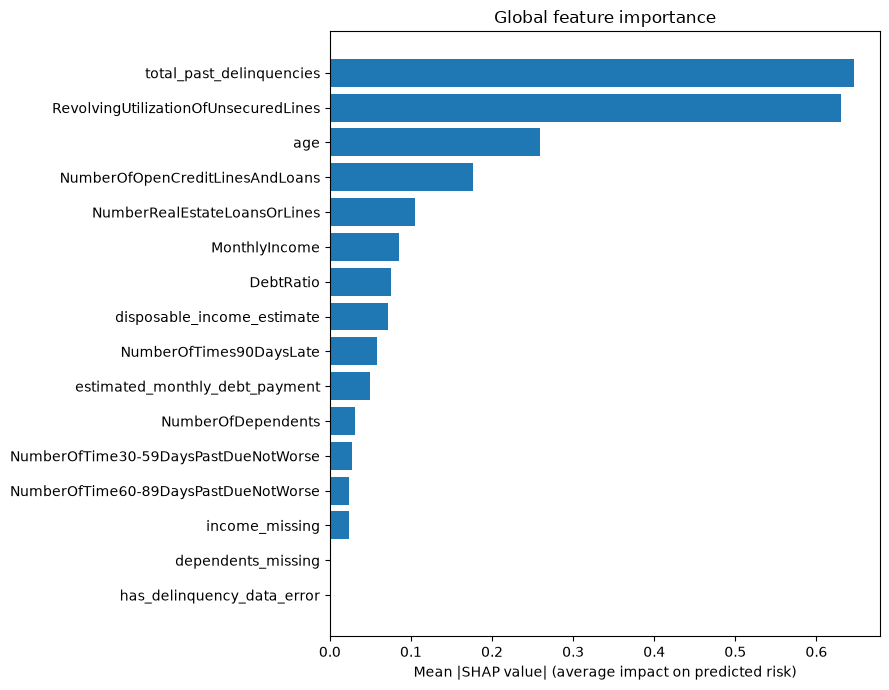

In [16]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(importance_df['feature'], importance_df['mean_abs_shap'])
plt.xlabel('Mean |SHAP value| (average impact on predicted risk)')
plt.title('Global feature importance')
plt.tight_layout()
plt.savefig('../data/processed/shap_global_importance.png', dpi=150)
plt.show()


## Explaining an Individual High-Risk Prediction

Rather than selecting a random applicant, the analysis isolates the individual evaluated as the highest risk in the test set. This provides a compelling, concrete case study for interviews and stakeholder presentations. 

The resulting visualization breaks down the specific drivers behind the score using standard directional indicators: red contributions push the predicted default risk upward, while blue contributions pull it down. This granular breakdown turns an opaque risk probability into a clear, explainable narrative for individual credit decisions.

Highest-risk applicant - predicted risk score: 97.1%


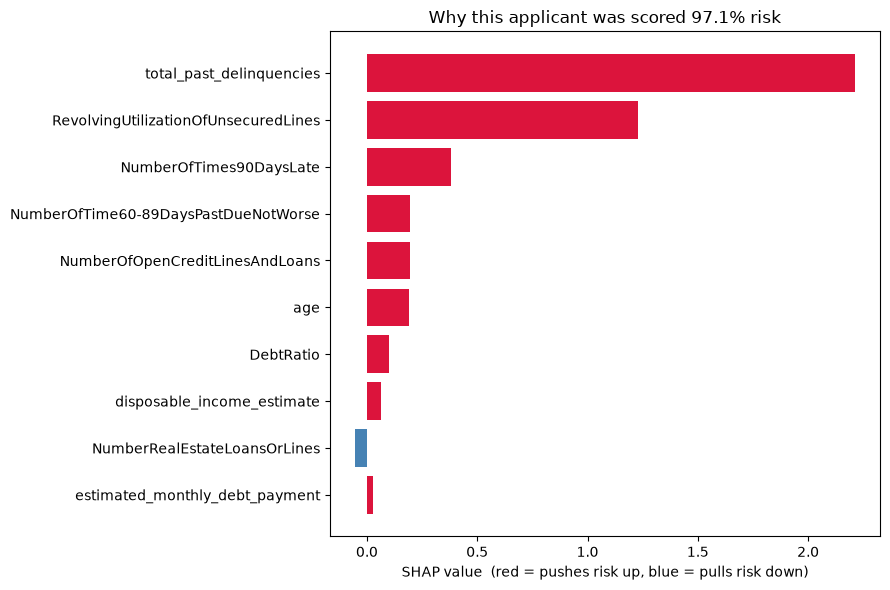

In [17]:
risk_scores = final_model.predict_proba(X_test)[:, 1]
highest_risk_idx = np.argmax(risk_scores)
print(f"Highest-risk applicant - predicted risk score: {risk_scores[highest_risk_idx]:.1%}")

row_shap = shap_values[highest_risk_idx]
row_df = pd.DataFrame({'feature': X_test.columns, 'shap_value': row_shap})
row_df['abs_val'] = row_df['shap_value'].abs()
row_df = row_df.sort_values('abs_val').tail(10)  # top 10 contributing features

colors = ['crimson' if v > 0 else 'steelblue' for v in row_df['shap_value']]
plt.figure(figsize=(9, 6))
plt.barh(row_df['feature'], row_df['shap_value'], color=colors)
plt.xlabel('SHAP value  (red = pushes risk up, blue = pulls risk down)')
plt.title(f"Why this applicant was scored {risk_scores[highest_risk_idx]:.1%} risk")
plt.tight_layout()
plt.savefig('../data/processed/shap_individual_example.png', dpi=150)
plt.show()


## Saving SHAP Values for Downstream Recourse Analysis

The computed SHAP values are serialized to disk to eliminate redundant calculations in Phase 4, Part B. Saving these outputs preserves the processed explainability artifacts, ensuring a modular and efficient workflow as the project transitions into generating actionable customer recourse recommendations.

In [18]:
np.save('../data/processed/shap_values_test.npy', shap_values)
X_test.to_csv('../data/processed/X_test.csv')
print("Saved SHAP values and X_test for the recourse phase.")


Saved SHAP values and X_test for the recourse phase.


# Phase 4, Part B: Recourse and Actionable Recommendations

**Core Findings from Phase 4A**
* Total past delinquencies and revolving utilisation of unsecured lines dominate global importance. This is a legitimate and textbook credit risk signal.
* Age ranks third and is clearly separated from the features below it. This provides a genuine reason to treat the Phase 5 fairness check seriously rather than as a mere formality.
* Both data quality flags show near zero importance. This is strong evidence that the cleaning steps in Phase 2 did not leak noise into the model.
* The engineered affordability features hold moderate rank. They are far more useful for communicating results to a human audience than for boosting raw predictive power.

**Designing Actionable Recourse**
The key design decision here is that we must only suggest changes to factors a real applicant can actually control. Age cannot be altered. Historical delinquency counts cannot be undone. The number of dependents is not something we should advise anyone to change. Furthermore, the flags for missing income, missing dependents, and delinquency data errors are simply artifacts of our own cleaning pipeline rather than real applicant attributes. Recommending that an applicant fix these would be entirely meaningless. This leaves a small and highly defensible set of actionable targets: revolving utilisation and debt ratio.

**Architectural Choice**
This logic now resides permanently in `src/recourse.py` rather than solely in this notebook. The Phase 6 dashboard will import these exact same functions. This creates a single source of truth for actionable features and prevents the notebook and the dashboard from quietly drifting apart.

In [19]:
import sys
sys.path.append('..')  # so we can import the src package from inside notebooks/

import pandas as pd
import numpy as np
import joblib
from src.recourse import ACTIONABLE_FEATURES, EXCLUDED_FEATURES, simulate_change, get_recourse_scenarios

X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0)
final_model = joblib.load('../data/processed/credit_risk_model.joblib')
shap_values = np.load('../data/processed/shap_values_test.npy')

# Same alignment as Part A - the saved X_test.csv always has every original
# column, even if the canonical model was later retrained without some of them
if hasattr(final_model, 'feature_names_in_'):
    X_test = X_test[list(final_model.feature_names_in_)]

print("Model's features:", list(X_test.columns))
print("Actionable features:", ACTIONABLE_FEATURES)
print("\nExcluded features and why:")
for feature, reason in EXCLUDED_FEATURES.items():
    print(f"  {feature}: {reason}")


Model's features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'income_missing', 'dependents_missing', 'has_delinquency_data_error', 'estimated_monthly_debt_payment', 'disposable_income_estimate', 'total_past_delinquencies']
Actionable features: ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio']

Excluded features and why:
  age: immutable
  NumberOfDependents: not appropriate to suggest changing
  total_past_delinquencies: historical - cannot be undone
  NumberOfTimes90DaysLate: historical - cannot be undone
  NumberOfTime30-59DaysPastDueNotWorse: historical - cannot be undone
  NumberOfTime60-89DaysPastDueNotWorse: historical - cannot be undone
  income_missing: pipeline artifact, not a real applicant attribute
  dependents_missing: pipeline artifact, not 

## Selecting a Borderline Applicant

Recourse advice provides the most value when applied to individuals who sit right on the edge of approval. If an applicant already carries a predicted risk of 97 percent, suggesting a few modest financial changes will not meaningfully alter their outcome. To demonstrate how this works in practice, we deliberately isolate the individual in the test set whose predicted risk score is closest to 50 percent. This ensures our analysis focuses on a genuinely borderline case where practical, achievable interventions could actually reverse a negative credit decision.

In [20]:
risk_scores = final_model.predict_proba(X_test)[:, 1]
demo_idx_pos = np.argmin(np.abs(risk_scores - 0.5))
demo_row = X_test.iloc[demo_idx_pos].copy()

print(f"Demo applicant - current predicted risk score: {risk_scores[demo_idx_pos]:.1%}")
print(demo_row[['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome',
                 'estimated_monthly_debt_payment', 'disposable_income_estimate']])


Demo applicant - current predicted risk score: 50.0%
RevolvingUtilizationOfUnsecuredLines       0.902300
DebtRatio                                  0.210107
MonthlyIncome                           7400.000000
estimated_monthly_debt_payment          1554.789891
disposable_income_estimate              5845.210109
Name: 135690, dtype: float64


## Understanding the Specific Score Drivers

This step applies the exact same logic used for individual explanations in Part A, but focuses entirely on our chosen borderline applicant. By doing this, we directly connect the SHAP explainability work to the practical recourse scenarios we are about to simulate.

In [21]:
row_shap = shap_values[demo_idx_pos]
row_df = pd.DataFrame({'feature': X_test.columns, 'shap_value': row_shap})
row_df['abs_val'] = row_df['shap_value'].abs()
row_df.sort_values('abs_val', ascending=False).head(5)[['feature', 'shap_value']]


,feature,shap_value
0,RevolvingUtilizationOfUnsecuredLines,1.486680
15,total_past_delinquencies,-0.356780
1,age,0.216904
14,disposable_income_estimate,-0.177953
7,NumberRealEstateLoansOrLines,0.074403


## Simulating Actionable Changes Through Model Recalculation

SHAP values provide a local and approximate explanation for one specific prediction. For a genuinely different hypothetical scenario, manually adding SHAP values is unreliable on a nonlinear model like gradient boosting. The most trustworthy approach is to alter the input data directly and ask the model to generate a fresh prediction. This is precisely the mechanism behind the `get_recourse_scenarios` function.

Furthermore, altering a single metric like the debt ratio in isolation is insufficient. Since the estimated monthly debt payment and disposable income estimate are derived directly from the debt ratio, the `simulate_change` function recalculates both automatically. This critical step guarantees that the hypothetical applicant profile remains completely consistent internally before the model evaluates it again.

In [22]:
baseline_score, results = get_recourse_scenarios(demo_row, final_model)

print(f"Baseline risk score: {baseline_score:.1%}\n")
for label, new_score in results:
    print(f"{label}: {new_score:.1%}  (change: {new_score - baseline_score:+.1%})")


Baseline risk score: 50.0%

Reduce revolving utilisation by 50%: 25.6%  (change: -24.4%)
Reduce revolving utilisation by 50% AND debt ratio by 30%: 26.8%  (change: -23.2%)
Reduce revolving utilisation by 25%: 36.9%  (change: -13.1%)
Reduce debt ratio by 15%: 50.0%  (change: +0.0%)
Reduce debt ratio by 30%: 51.1%  (change: +1.1%)


## Generating the Consumer View Message

This step produces output that closely mirrors the final consumer view on the Phase 6 dashboard. We explicitly state the estimated impact rather than promising a guaranteed outcome. The model is highly effective at calculating how specific financial adjustments will likely alter its own predicted score. However, it cannot make absolute guarantees about whether a real lending institution will ultimately approve a final loan application.

In [23]:
best_label, best_score = results[0]

print("=" * 60)
print(f"YOUR ESTIMATED RISK SCORE: {baseline_score:.0%}")
print("=" * 60)
print(f"\nBased on this model, here's what could improve your score:\n")
for label, new_score in results[:3]:
    point_drop = (baseline_score - new_score) * 100
    print(f"  - {label}")
    print(f"    Estimated new score: {new_score:.0%} "
          f"(a reduction of roughly {point_drop:.0f} percentage points)\n")
print("These are model estimates based on historical patterns, not a")
print("guarantee of approval or a promise about how a real lender would respond.")


YOUR ESTIMATED RISK SCORE: 50%

Based on this model, here's what could improve your score:

  - Reduce revolving utilisation by 50%
    Estimated new score: 26% (a reduction of roughly 24 percentage points)

  - Reduce revolving utilisation by 50% AND debt ratio by 30%
    Estimated new score: 27% (a reduction of roughly 23 percentage points)

  - Reduce revolving utilisation by 25%
    Estimated new score: 37% (a reduction of roughly 13 percentage points)

These are model estimates based on historical patterns, not a
guarantee of approval or a promise about how a real lender would respond.


## Notebook Completion and Summary

This concludes the explainability and recourse phase of the project. We have successfully transformed an opaque machine learning model into a transparent system capable of generating practical and actionable advice for borderline applicants. By centralising the recourse logic within a dedicated Python module, we have established a single source of truth that will power the interactive dashboard in the final phase.

In the first half of this analysis, we discovered that age holds significant predictive weight within our model. This finding makes our next step absolutely critical. Moving into Phase 5, we will conduct a rigorous fairness audit to ensure that this reliance on demographic data does not introduce systemic bias or unfairly disadvantage protected groups.